
# A Multi-Fidelity Dataset: MD Benzene

This tutorial covers the basics of data handling, visualization, and structural
representation generation in MFML-QC. We will use an inbuilt dataset for the benzene molecule.

## Dataset Details
The dataset for benzene is taken from the work presented in
J. Chem. Theory Comput. 2023, 19, 21, 7658–7670 (10.1021/acs.jctc.3c00882).
The dataset consists of 15,000 fs MD-simulation of benzene with details of simulation presented
in the article above. For the geometries of this simulation, a sparse multifidelity dataset of excitation energies is provided.
Below (and in a few more tutorials) we will interact with this toy dataset to better understand the MFML-4-QC package.

## Downloading the Dataset
The Benzene dataset is built into the package to allow for quick benchmarking.
If you encounter a ``FileNotFoundError`` during this tutorial, ensure you have
installed the package using ``pip install .`` from the root directory so the
dataset is correctly packaged, or manually place the data files inside the
``data/benzene`` directory.


## Loading the Built-in Dataset
We start by loading the built-in dataset using our provided utility function.
This automatically handles path resolution and caching for you.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfml_qc.datasets import load_benzene_data

dataset = load_benzene_data()

# Let's inspect what the dataset dictionary contains.
print(f"Keys in dataset: {list(dataset.keys())}")
print(f"Columns in CSV: {dataset['columns']}")

/home/vvinod/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keys in dataset: ['X_CM', 'energies', 'timecosts', 'columns']
Columns in CSV: ['Time', 'ZINDO', 'LC-DFTB', 'STO-3G', '3-21G', '6-31G', 'def2-SVP', 'def2-TZVP', 'def2-QZVP']


## Exploring the Data
The data consists of vertical excitation energies computed at multiple fidelities
and their corresponding computational time costs. Let's extract them and look
at the distributions.



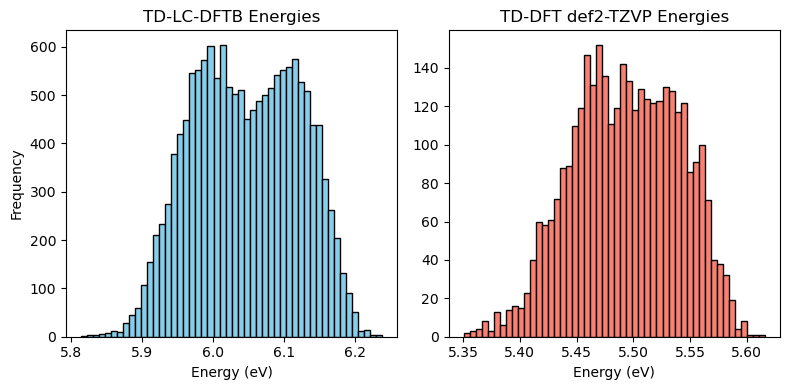

In [2]:
energies = dataset["energies"]
timecosts = dataset["timecosts"]

# From our columns list, LC-DFTB is at index 2, and def2-TZVP is at index 7.
lc_dftb_energies = energies[:, 2]
def2_tzvp_energies = energies[:, 7]

# Drop NaN values for the plot
# (high-fidelity calculations are sparsely computed)
lc_dftb_clean = lc_dftb_energies[~np.isnan(lc_dftb_energies)]
def2_tzvp_clean = def2_tzvp_energies[~np.isnan(def2_tzvp_energies)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.hist(lc_dftb_clean, bins=50, color="skyblue", edgecolor="black")
ax1.set_title("TD-LC-DFTB Energies")
ax1.set_xlabel("Energy (eV)")
ax1.set_ylabel("Frequency")

ax2.hist(def2_tzvp_clean, bins=50, color="salmon", edgecolor="black")
ax2.set_title("TD-DFT def2-TZVP Energies")
ax2.set_xlabel("Energy (eV)")

plt.tight_layout()
plt.show()

## Why Multi-Fidelity Machine Learning?
Multi-fidelity machine learning relies on the fact that lower levels of theory
are significantly cheaper to compute. Let's visualize the computational time cost
distributions across all fidelities to see if we can make a case for MFML.

To ensure a fair comparison, we will extract a strict subset of geometries from
the training set (the first 12,288 samples) where the most expensive
calculation (def2-QZVP) is present.



Found 384 training geometries with complete hierarchy data.


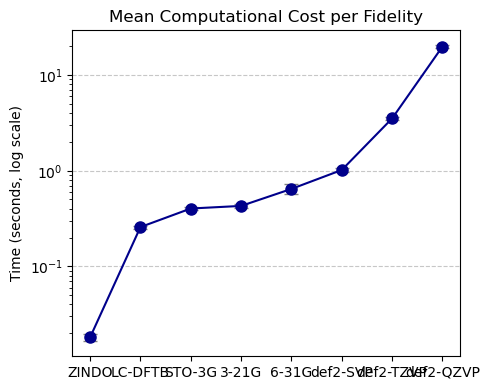

In [3]:
train_energies = energies[:12288]
train_timecosts = timecosts[:12288]

# def2-QZVP is at column index 8.
# We create a mask for rows where it is present.
valid_qzvp_mask = ~np.isnan(train_energies[:, 8])
filtered_timecosts = train_timecosts[valid_qzvp_mask]

print(
    f"Found {np.sum(valid_qzvp_mask)} training geometries with complete hierarchy data."
)

methods = [
    "ZINDO",
    "LC-DFTB",
    "STO-3G",
    "3-21G",
    "6-31G",
    "def2-SVP",
    "def2-TZVP",
    "def2-QZVP",
]
method_indices = [1, 2, 3, 4, 5, 6, 7, 8]

# Calculate means and standard deviations
means = [np.mean(filtered_timecosts[:, i]) for i in method_indices]
stds = [np.std(filtered_timecosts[:, i]) for i in method_indices]

# ---------------------------------------------------------
# Plotting Mean and Std Dev
# ---------------------------------------------------------
plt.figure(figsize=(5, 4))

# Plotting with error bars
plt.errorbar(
    range(len(methods)),
    means,
    yerr=stds,
    fmt="o-",
    capsize=5,
    elinewidth=2,
    markersize=8,
    color="darkblue",
    ecolor="gray",
)

plt.xticks(ticks=range(len(methods)), labels=methods)
plt.yscale("log")
plt.title("Mean Computational Cost per Fidelity")
plt.ylabel("Time (seconds, log scale)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Generating Molecular Representations
Machine learning models cannot read raw 3D Cartesian (XYZ) coordinates directly,
as they are not translationally or rotationally invariant. Instead, we map the
3D structures into a flattened 1D vector called the **Coulomb Matrix (CM)**.
This is one of the simplest molecular descriptors and we will use this throughout
the tutorials.

The ``load_benzene_data()`` function automatically invoked
routines to compute and load these representations for us.



In [4]:
X_CM = dataset["X_CM"]
print(f"Total Geometries: {X_CM.shape[0]}")
print(f"Coulomb Matrix Features per geometry: {X_CM.shape[1]}")

Total Geometries: 15000
Coulomb Matrix Features per geometry: 78


## Custom Datasets
If you are working with your own custom molecular dynamics trajectory (e.g., an
``.xyz`` file) instead of the built-in dataset, you can generate these representations
manually.

The representations module handles the file parsing and memory allocation automatically:



In [5]:
from mfml_qc.representations import generate_coulomb_matrices

# This is the exact command you would use on your own data:
# X_custom_CM = generate_coulomb_matrices(
#     xyz_filepath="path/to/your/custom_trajectory.xyz",
#     save_path="optional/path/to/cache_coulomb_matrices.npy"
# )